In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [2]:
# --- Load data ---
df = pd.read_excel("Concrete_Data.xls")
X = df.drop(columns=['Concrete compressive strength(MPa, megapascals) '])
y = df['Concrete compressive strength(MPa, megapascals) '].values

# --- Split into training and test set ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Standardize whole training set (for final evaluation later) ---
scaler_full = StandardScaler()
X_train_std = scaler_full.fit_transform(X_train)
X_test_std = scaler_full.transform(X_test)

Fold 1: λ*=2.7826, h*=4 ([16, 32, 64, 128]), Ridge MSE=122.97, ANN MSE=24.92, Baseline MSE=333.29
Fold 2: λ*=0.3594, h*=2 ([16, 32]), Ridge MSE=94.44, ANN MSE=29.51, Baseline MSE=236.90
Fold 3: λ*=0.0464, h*=2 ([16, 32]), Ridge MSE=144.46, ANN MSE=62.63, Baseline MSE=343.29
Fold 4: λ*=0.3594, h*=3 ([16, 32, 64]), Ridge MSE=90.76, ANN MSE=41.41, Baseline MSE=274.49
Fold 5: λ*=0.3594, h*=3 ([16, 32, 64]), Ridge MSE=123.60, ANN MSE=54.58, Baseline MSE=261.27
Fold 6: λ*=0.3594, h*=3 ([16, 32, 64]), Ridge MSE=139.59, ANN MSE=51.97, Baseline MSE=280.30
Fold 7: λ*=0.0001, h*=4 ([16, 32, 64, 128]), Ridge MSE=95.57, ANN MSE=40.12, Baseline MSE=279.38
Fold 8: λ*=0.3594, h*=1 ([16]), Ridge MSE=123.18, ANN MSE=43.02, Baseline MSE=280.14
Fold 9: λ*=0.3594, h*=3 ([16, 32, 64]), Ridge MSE=77.70, ANN MSE=32.57, Baseline MSE=272.62
Fold 10: λ*=0.3594, h*=4 ([16, 32, 64, 128]), Ridge MSE=122.72, ANN MSE=26.14, Baseline MSE=286.81


,Fold,λ*,h*,ANN neurons,Ridge Test MSE,ANN Test MSE,Baseline MSE
0,1,2.782559,4,"[16, 32, 64, 128]",122.967782,24.922583,333.285016
1,2,0.359381,2,"[16, 32]",94.437505,29.509828,236.903196
2,3,0.046416,2,"[16, 32]",144.463992,62.628125,343.287175
3,4,0.359381,3,"[16, 32, 64]",90.763079,41.408468,274.489578
4,5,0.359381,3,"[16, 32, 64]",123.599522,54.579981,261.274561
5,6,0.359381,3,"[16, 32, 64]",139.591729,51.966716,280.304005
6,7,0.000100,4,"[16, 32, 64, 128]",95.568788,40.119351,279.378598
7,8,0.359381,1,[16],123.184065,43.015994,280.144982
8,9,0.359381,3,"[16, 32, 64]",77.696075,32.569511,272.622592
9,10,0.359381,4,"[16, 32, 64, 128]",122.724634,26.141762,286.810173



Average Test MSEs (Outer CV):
Ridge Test MSE    113.499717
ANN Test MSE       40.686232
Baseline MSE      284.849988
dtype: float64


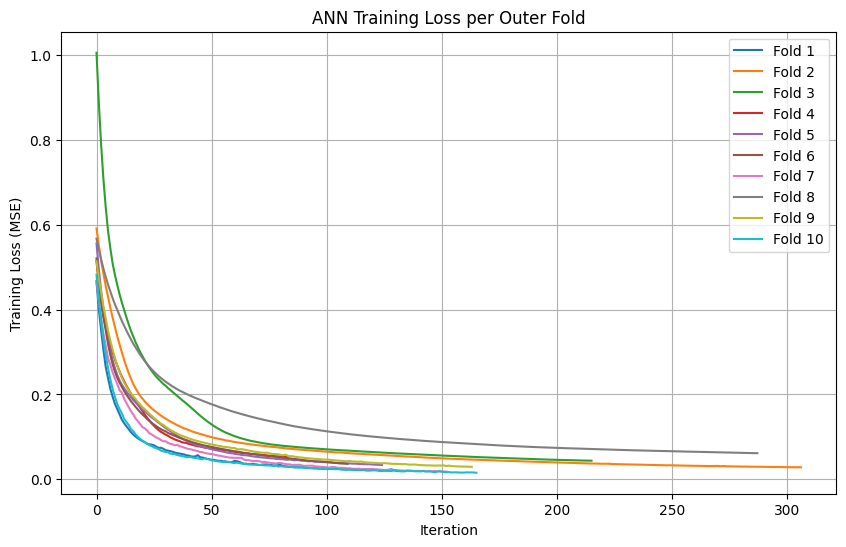


Final Evaluation on Held-out Test Set:
Ridge RMSE: 9.797
ANN RMSE:   5.561
Baseline:   16.054


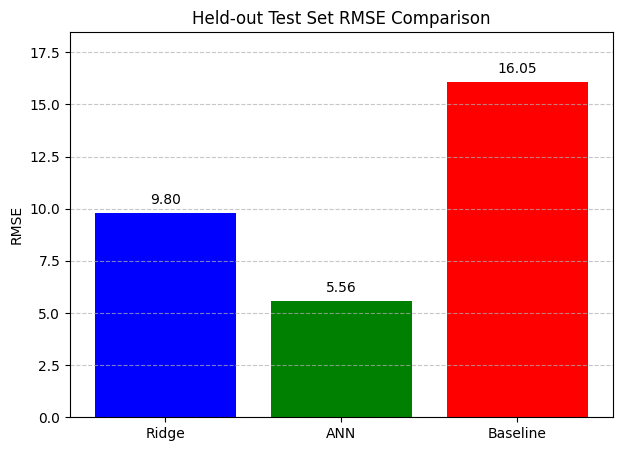

In [3]:
# --- Nested CV settings ---
K1 = K2 = 10
outer_cv = KFold(n_splits=K1, shuffle=True, random_state=42)
lambdas = np.logspace(-4, 4, 10)      # Ridge hyperparameter
h_values = [1, 2, 3, 4]                   # Number of hidden layers for ANN

# --- Store results ---
results = []
ann_loss_curves = []

# --- Outer CV ---
fold_number = 1
for train_idx, test_idx in outer_cv.split(X_train):
    # Split original (unscaled) training data
    X_train_outer, X_test_outer = X_train.iloc[train_idx], X_train.iloc[test_idx]
    y_train_outer, y_test_outer = y_train[train_idx], y_train[test_idx]

    # Scale features per fold
    scaler = StandardScaler()
    X_train_outer_std = scaler.fit_transform(X_train_outer)
    X_test_outer_std = scaler.transform(X_test_outer)

    # Optionally scale target for ANN
    y_scaler = StandardScaler()
    y_train_outer_s = y_scaler.fit_transform(y_train_outer.reshape(-1,1)).ravel()

    # --- Inner CV ---
    inner_cv = KFold(n_splits=K2, shuffle=True, random_state=fold_number)

    # --- Ridge inner loop ---
    ridge_scores = []
    for l in lambdas:
        inner_mse = []
        for itrain, ival in inner_cv.split(X_train_outer_std):
            ridge = Ridge(alpha=l)
            ridge.fit(X_train_outer_std[itrain], y_train_outer[itrain])
            y_val_pred = ridge.predict(X_train_outer_std[ival])
            inner_mse.append(mean_squared_error(y_train_outer[ival], y_val_pred))
        ridge_scores.append(np.mean(inner_mse))
    best_lambda = lambdas[np.argmin(ridge_scores)]

    # --- ANN inner loop ---
    ann_scores = []
    for h in h_values:
        inner_mse = []
        # Build increasing neuron architecture per layer
        neurons = [16 * (2**i) for i in range(h)]  # e.g. h=1 -> [16], h=2 -> [16,32], h=3 -> [16,32,64]
        for itrain, ival in inner_cv.split(X_train_outer_std):
            ann = MLPRegressor(hidden_layer_sizes=tuple(neurons),
                               max_iter=3000,
                               early_stopping=True,
                               random_state=fold_number)
            ann.fit(X_train_outer_std[itrain], y_train_outer_s[itrain])
            y_val_pred_s = ann.predict(X_train_outer_std[ival])
            y_val_pred = y_scaler.inverse_transform(y_val_pred_s.reshape(-1,1)).ravel()
            inner_mse.append(mean_squared_error(y_train_outer[ival], y_val_pred))
        ann_scores.append(np.mean(inner_mse))
    best_h = h_values[np.argmin(ann_scores)]
    best_neurons = [16*(2**i) for i in range(best_h)]

    # --- Evaluate models on outer test set ---
    # Ridge
    ridge_final = Ridge(alpha=best_lambda)
    ridge_final.fit(X_train_outer_std, y_train_outer)
    ridge_test_mse = mean_squared_error(y_test_outer, ridge_final.predict(X_test_outer_std))

    # ANN
    ann_final = MLPRegressor(hidden_layer_sizes=tuple(best_neurons),
                             max_iter=3000,
                             early_stopping=True,
                             random_state=fold_number)
    ann_final.fit(X_train_outer_std, y_train_outer_s)
    y_pred_s = ann_final.predict(X_test_outer_std)
    y_pred = y_scaler.inverse_transform(y_pred_s.reshape(-1,1)).ravel()
    ann_test_mse = mean_squared_error(y_test_outer, y_pred)
    ann_loss_curves.append(ann_final.loss_curve_)

    # Baseline
    baseline_pred = np.full_like(y_test_outer, y_train_outer.mean())
    baseline_mse = mean_squared_error(y_test_outer, baseline_pred)

    # Store results
    results.append({
        'Fold': fold_number,
        'λ*': best_lambda,
        'h*': best_h,
        'ANN neurons': best_neurons,
        'Ridge Test MSE': ridge_test_mse,
        'ANN Test MSE': ann_test_mse,
        'Baseline MSE': baseline_mse
    })

    print(f"Fold {fold_number}: λ*={best_lambda:.4f}, h*={best_h} ({best_neurons}), "
          f"Ridge MSE={ridge_test_mse:.2f}, ANN MSE={ann_test_mse:.2f}, "
          f"Baseline MSE={baseline_mse:.2f}")

    fold_number += 1

# --- Display results table ---
results_df = pd.DataFrame(results)
display(results_df)

print("\nAverage Test MSEs (Outer CV):")
print(results_df[['Ridge Test MSE', 'ANN Test MSE', 'Baseline MSE']].mean())

# --- Plot ANN loss curves ---
plt.figure(figsize=(10,6))
for i, loss_curve in enumerate(ann_loss_curves):
    plt.plot(loss_curve, label=f'Fold {i+1}')
plt.xlabel('Iteration')
plt.ylabel('Training Loss (MSE)')
plt.title('ANN Training Loss per Outer Fold')
plt.legend()
plt.grid(True)
plt.show()

# --- Final evaluation on untouched test set ---
best_lambda_global = results_df['λ*'].mode()[0]
best_h_global = results_df['h*'].mode()[0]
best_neurons_global = [16*(2**i) for i in range(best_h_global)]

# Ridge
ridge_final_global = Ridge(alpha=best_lambda_global)
ridge_final_global.fit(X_train_std, y_train)
ridge_test_rmse = np.sqrt(mean_squared_error(y_test, ridge_final_global.predict(X_test_std)))

# ANN
y_train_scaled = StandardScaler().fit_transform(y_train.reshape(-1,1)).ravel()
ann_final_global = MLPRegressor(hidden_layer_sizes=tuple(best_neurons_global),
                                max_iter=3000,
                                early_stopping=True,
                                random_state=42)
ann_final_global.fit(X_train_std, y_train_scaled)
y_pred_s = ann_final_global.predict(X_test_std)
y_pred = StandardScaler().fit(y_train.reshape(-1,1)).inverse_transform(y_pred_s.reshape(-1,1)).ravel()
ann_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Baseline
baseline_rmse = np.sqrt(mean_squared_error(y_test, np.full_like(y_test, y_train.mean())))

print(f"\nFinal Evaluation on Held-out Test Set:")
print(f"Ridge RMSE: {ridge_test_rmse:.3f}")
print(f"ANN RMSE:   {ann_test_rmse:.3f}")
print(f"Baseline:   {baseline_rmse:.3f}")

# --- Optional: bar plot of held-out test RMSE ---
models = ['Ridge', 'ANN', 'Baseline']
rmse_values = [ridge_test_rmse, ann_test_rmse, baseline_rmse]

plt.figure(figsize=(7,5))
bars = plt.bar(models, rmse_values, color=['blue','green','red'])
plt.ylabel('RMSE')
plt.title('Held-out Test Set RMSE Comparison')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, max(rmse_values)*1.15)  # padding for labels

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.3, f'{height:.2f}',
             ha='center', va='bottom')
plt.show()

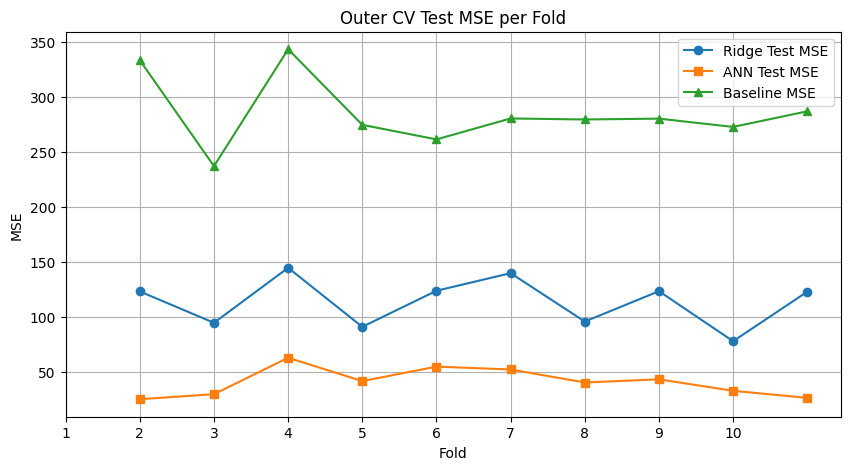

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Outer CV per fold
folds = results_df['Fold'].values
ridge_mse = results_df['Ridge Test MSE'].values
ann_mse = results_df['ANN Test MSE'].values
baseline_mse = results_df['Baseline MSE'].values

plt.figure(figsize=(10,5))
plt.plot(folds+1, ridge_mse, marker='o', label='Ridge Test MSE')
plt.plot(folds+1, ann_mse, marker='s', label='ANN Test MSE')
plt.plot(folds+1, baseline_mse, marker='^', label='Baseline MSE')
plt.xlabel('Fold')
plt.ylabel('MSE')
plt.title('Outer CV Test MSE per Fold')
plt.xticks(folds)
plt.grid(True)
plt.legend()
plt.show()


Paired t-test Results:

ANN vs Ridge:
  t-statistic = -382.318
  p-value     = < 1e-10
  95% CI      = (-73.191, -72.443)

ANN vs Baseline:
  t-statistic = -547.477
  p-value     = < 1e-10
  95% CI      = (-245.104, -243.352)

Ridge vs Baseline:
  t-statistic = -394.785
  p-value     = < 1e-10
  95% CI      = (-172.263, -170.559)



C:\Users\alexd\AppData\Local\Temp\ipykernel_50512\453420149.py:101: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(errors, labels=models, patch_artist=True,


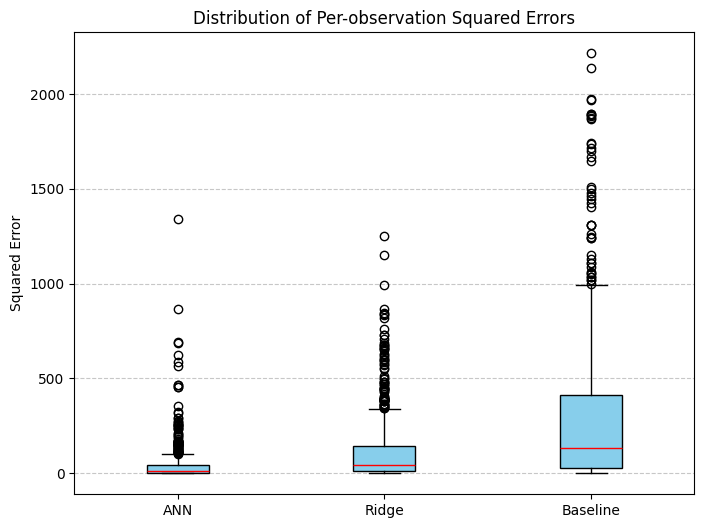

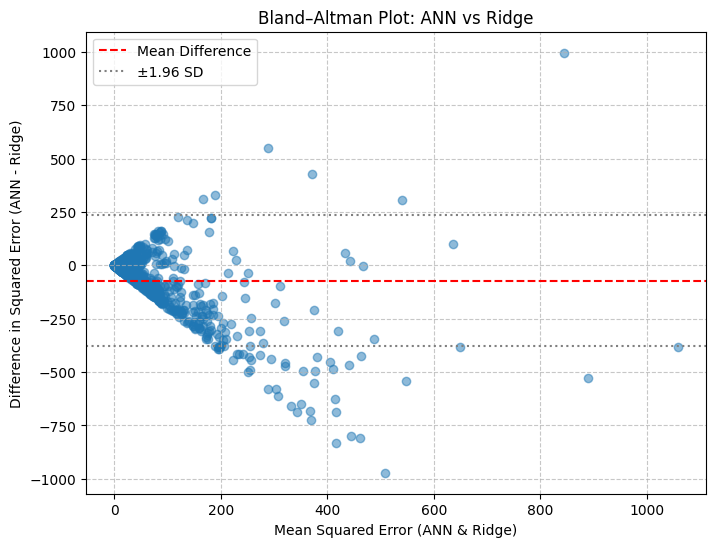

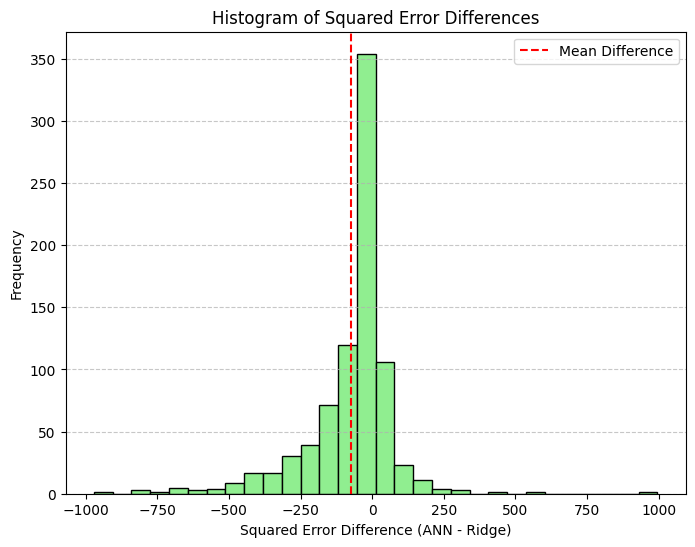

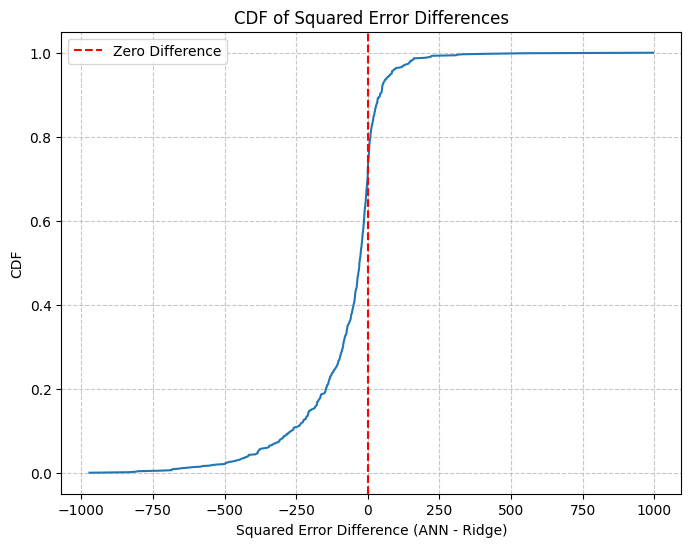

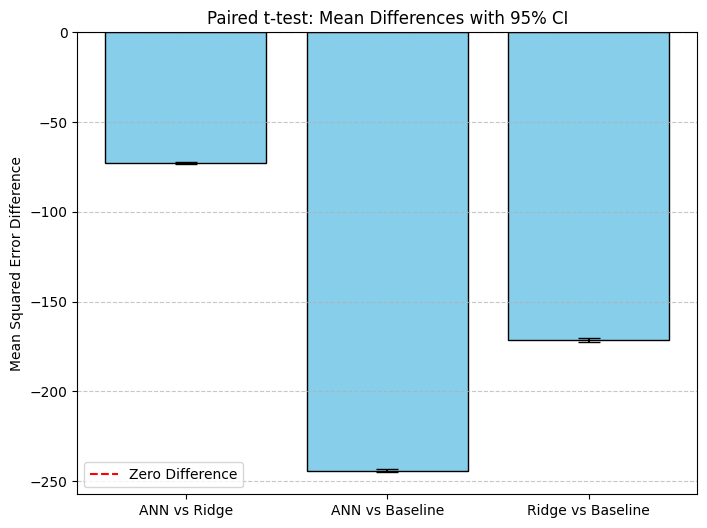

In [9]:
from scipy import stats
import numpy as np

# --- Collect per-observation squared errors per fold ---
z_ann_list = []
z_ridge_list = []
z_base_list = []

outer_cv = KFold(n_splits=K1, shuffle=True, random_state=42)
fold_number = 1

for train_idx, test_idx in outer_cv.split(X_train):
    X_train_outer, X_test_outer = X_train.iloc[train_idx], X_train.iloc[test_idx]
    y_train_outer, y_test_outer = y_train[train_idx], y_train[test_idx]

    # Scale features
    scaler = StandardScaler()
    X_train_outer_std = scaler.fit_transform(X_train_outer)
    X_test_outer_std = scaler.transform(X_test_outer)

    # Scale target for ANN
    y_scaler = StandardScaler()
    y_train_outer_s = y_scaler.fit_transform(y_train_outer.reshape(-1,1)).ravel()

    # --- Fit Ridge ---
    best_lambda = results_df.loc[fold_number-1, 'λ*']
    ridge = Ridge(alpha=best_lambda)
    ridge.fit(X_train_outer_std, y_train_outer)
    y_pred_ridge = ridge.predict(X_test_outer_std)
    
    # --- Fit ANN ---
    best_neurons = results_df.loc[fold_number-1, 'ANN neurons']
    ann = MLPRegressor(hidden_layer_sizes=tuple(best_neurons),
                       max_iter=3000, early_stopping=True, random_state=fold_number)
    ann.fit(X_train_outer_std, y_train_outer_s)
    y_pred_s = ann.predict(X_test_outer_std)
    y_pred_ann = y_scaler.inverse_transform(y_pred_s.reshape(-1,1)).ravel()

    # --- Baseline ---
    y_pred_base = np.full_like(y_test_outer, y_train_outer.mean())

    # --- Per-observation squared errors ---
    z_ann_list.append((y_test_outer - y_pred_ann)**2)
    z_ridge_list.append((y_test_outer - y_pred_ridge)**2)
    z_base_list.append((y_test_outer - y_pred_base)**2)

    fold_number += 1

# --- Flatten squared errors per fold for paired t-test ---
# Note: lengths must match per fold (same test set size)
def flatten_list_of_arrays(list_of_arrays):
    return np.concatenate(list_of_arrays)

z_ann_all = flatten_list_of_arrays(z_ann_list)
z_ridge_all = flatten_list_of_arrays(z_ridge_list)
z_base_all = flatten_list_of_arrays(z_base_list)

# --- Paired t-test function ---
def paired_t_test(z_model1, z_model2, alpha=0.05):
    d = z_model1 - z_model2
    n = len(d)
    d_mean = np.mean(d)
    s_d = np.sqrt(np.sum((d - d_mean)**2) / (n*(n-1)))
    t_stat = d_mean / (s_d / np.sqrt(n))
    p_value = 2 * (1 - stats.t.cdf(np.abs(t_stat), df=n-1))
    t_crit = stats.t.ppf(1 - alpha/2, df=n-1)
    ci_lower = d_mean - t_crit * s_d / np.sqrt(n)
    ci_upper = d_mean + t_crit * s_d / np.sqrt(n)
    return t_stat, p_value, (ci_lower, ci_upper)

# --- Perform paired t-tests and print results with formatted p-values ---
tests = {
    "ANN vs Ridge": (z_ann_all, z_ridge_all),
    "ANN vs Baseline": (z_ann_all, z_base_all),
    "Ridge vs Baseline": (z_ridge_all, z_base_all)
}

print("Paired t-test Results:\n")
for name, (z1, z2) in tests.items():
    t_stat, p_val, ci = paired_t_test(z1, z2)
    
    # Format p-value for reporting
    if p_val < 1e-10:
        p_val_str = "< 1e-10"
    else:
        p_val_str = f"{p_val:.6f}"
    
    print(f"{name}:")
    print(f"  t-statistic = {t_stat:.3f}")
    print(f"  p-value     = {p_val_str}")
    print(f"  95% CI      = ({ci[0]:.3f}, {ci[1]:.3f})\n")



# Flattened per-observation squared errors
models = ['ANN', 'Ridge', 'Baseline']
errors = [z_ann_all, z_ridge_all, z_base_all]

# --- 1. Boxplot of squared errors ---
plt.figure(figsize=(8,6))
plt.boxplot(errors, labels=models, patch_artist=True,
            boxprops=dict(facecolor='skyblue', color='black'),
            medianprops=dict(color='red'))
plt.ylabel('Squared Error')
plt.title('Distribution of Per-observation Squared Errors')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

mean_pred = (z_ann_all + z_ridge_all)/2
diff = z_ann_all - z_ridge_all

plt.figure(figsize=(8,6))
plt.scatter(mean_pred, diff, alpha=0.5)
plt.axhline(np.mean(diff), color='red', linestyle='--', label='Mean Difference')
plt.axhline(np.mean(diff) + 1.96*np.std(diff), color='gray', linestyle=':', label='±1.96 SD')
plt.axhline(np.mean(diff) - 1.96*np.std(diff), color='gray', linestyle=':')
plt.xlabel('Mean Squared Error (ANN & Ridge)')
plt.ylabel('Difference in Squared Error (ANN - Ridge)')
plt.title('Bland–Altman Plot: ANN vs Ridge')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# --- 3. Histogram of differences (ANN - Ridge) ---
diff_ann_ridge = z_ann_all - z_ridge_all
plt.figure(figsize=(8,6))
plt.hist(diff_ann_ridge, bins=30, color='lightgreen', edgecolor='black')
plt.axvline(np.mean(diff_ann_ridge), color='red', linestyle='--', label='Mean Difference')
plt.xlabel('Squared Error Difference (ANN - Ridge)')
plt.ylabel('Frequency')
plt.title('Histogram of Squared Error Differences')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

diff = z_ann_all - z_ridge_all
diff_sorted = np.sort(diff)
cdf = np.arange(1, len(diff_sorted)+1)/len(diff_sorted)

plt.figure(figsize=(8,6))
plt.plot(diff_sorted, cdf, marker='', linestyle='-')
plt.axvline(0, color='red', linestyle='--', label='Zero Difference')
plt.xlabel('Squared Error Difference (ANN - Ridge)')
plt.ylabel('CDF')
plt.title('CDF of Squared Error Differences')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

import matplotlib.pyplot as plt

# --- Compute mean differences and CIs ---
comparisons = ["ANN vs Ridge", "ANN vs Baseline", "Ridge vs Baseline"]
mean_diff = []
ci_lower = []
ci_upper = []

for name, (z1, z2) in tests.items():
    t_stat, p_val, ci = paired_t_test(z1, z2)
    mean_diff.append(np.mean(z1 - z2))
    ci_lower.append(np.mean(z1 - z2) - ci[0])
    ci_upper.append(ci[1] - np.mean(z1 - z2))

# --- Bar plot with error bars (CI) ---
plt.figure(figsize=(8,6))
plt.bar(comparisons, mean_diff, yerr=[ci_lower, ci_upper], capsize=8, color='skyblue', edgecolor='black')
plt.axhline(0, color='red', linestyle='--', label='Zero Difference')
plt.ylabel('Mean Squared Error Difference')
plt.title('Paired t-test: Mean Differences with 95% CI')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()
